# Przewidywanie wyroków sądu

**Zadanie 1**

Proszę zaimportować dane z linku:

[hf://datasets/glnmario/ECHR/ECHR_Dataset.csv](hf://datasets/glnmario/ECHR/ECHR_Dataset.csv)

In [ ]:
import pandas as pd

dataset = pd.read_csv("hf://datasets/glnmario/ECHR/ECHR_Dataset.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


**Zadanie 2.**

Proszę przygotować dane do modelowania wykonując następujące czynności:

1) proszę podzielić dane na zmienne niezależne i na zmienną zależną. Kolejne kroki proszę wykonywać na zmiennych niezależnych,
2) proszę usunąć kolumny `'partition', 'itemid', 'docname', 'conclusion', 'languageisocode'`,
3) proszę wystandaryzować kolumny numeryczne,
4) proszę zwektoryzować kolumnę `'test'` za pomocą TF-IDF,
5) proszę przeprowadzić one-hot-encoding na pozostałych kolumnach tekstowych.
6) proszę się upewnić, że wszystkie zmienne niezależne są w jednej macierzy, a zmienna zależna jest wektorem.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
vectorizer = TfidfVectorizer()

df = dataset.drop(['partition', 'itemid', 'docname', 'conclusion', 'languageisocode'], axis=1)
pre_X = df.drop(['binary_judgement'], axis = 1)
Y = dataset['binary_judgement']

pre_X_one_hot = pre_X.drop(['text', 'date', 'importance'], axis = 1)
pre_X_numeric = pre_X[['date', 'importance']].copy()
pre_X_numeric[['date', 'importance']] = scaler.fit_transform(pre_X_numeric[['date', 'importance']])
pre_X_vec = pre_X['text']

X_encoded = pd.get_dummies(pre_X_one_hot)
X_vec = vectorizer.fit_transform(pre_X_vec)

X_encoded_sparse = csr_matrix(X_encoded.values)
pre_X_numeric_sparse = csr_matrix(pre_X_numeric.values)

X = hstack([X_vec, X_encoded_sparse, pre_X_numeric_sparse])

**Zadanie 3.**

Proszę podzielić dane na dane uczące i dane testowe. Proszę zadbać o zrównoważenie danych.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.5, random_state=42)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_vec, Y, test_size=0.5, random_state=42)

**Zadanie 4.**

Proszę dopasować do danych uczących model regresji logistycznej.

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(solver='saga', max_iter=1000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='saga')

**Zadanie 5.**

Proszę dopasować do danych uczących model naiwnego klasyfikatora bayesowskiego.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train_2, y_train_2)

MultinomialNB()

**Zadanie 6.**

Proszę dokonać predykcji zmiennej zależnej za pomocą wyżej dopasowanych modeli. Dodatkowo proszę dokonać predykcji losowej oraz takiej, która zawsze przewiduje 1. Następnie proszę narysować ROC dla każdego modelu i macierze pomyłek.

Confusion Matrix - Logistic Regression


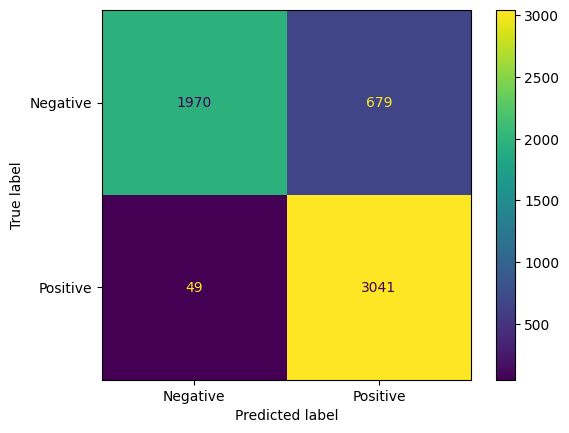

Confusion Matrix - Naive Bayes


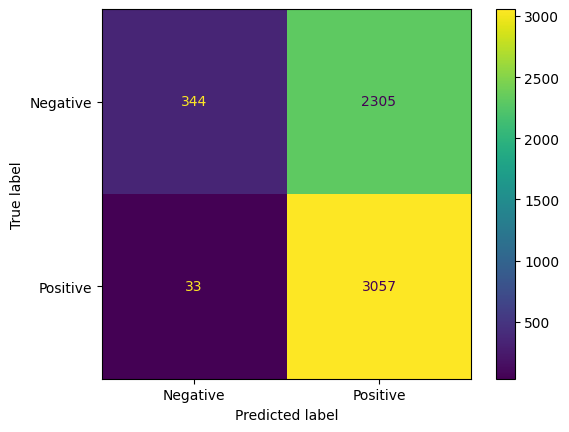

Confusion Matrix - Random Classifier


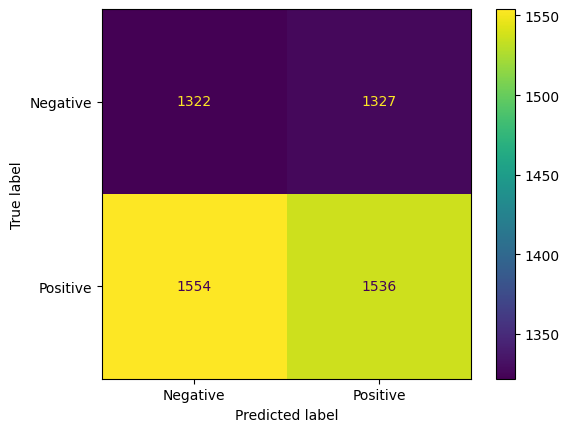

Confusion Matrix - Constant Classifier (all 1)


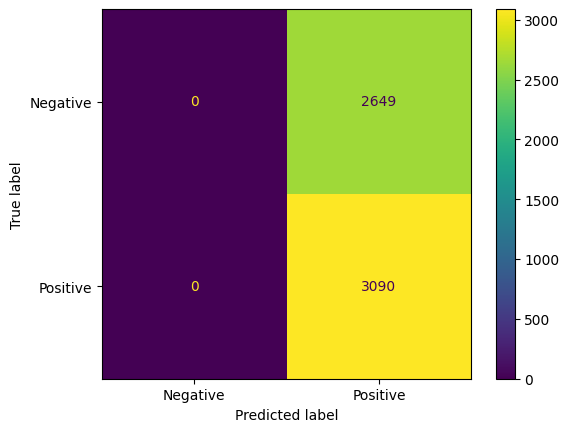

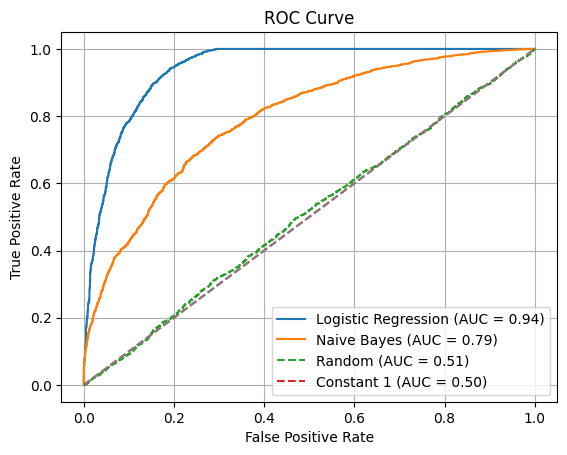

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

y_pred_lr = model_lr.predict(X_test)
y_pred_nb = model_nb.predict(X_test_2)

y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
y_prob_nb = model_nb.predict_proba(X_test_2)[:, 1]

np.random.seed(42)
y_pred_random = np.random.randint(0, 2, size=len(y_test))
y_prob_random = np.random.rand(len(y_test))

y_pred_const = np.ones(len(y_test), dtype=int)
y_prob_const = np.ones(len(y_test))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nb = confusion_matrix(y_test_2, y_pred_nb)
cm_random = confusion_matrix(y_test, y_pred_random)
cm_const = confusion_matrix(y_test, y_pred_const)


disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Negative", "Positive"])
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Negative", "Positive"])
disp_random = ConfusionMatrixDisplay(confusion_matrix=cm_random, display_labels=["Negative", "Positive"])
disp_const = ConfusionMatrixDisplay(confusion_matrix=cm_const, display_labels=["Negative", "Positive"])

print("Confusion Matrix - Logistic Regression")
disp_lr.plot()
plt.show()

print("Confusion Matrix - Naive Bayes")
disp_nb.plot()
plt.show()

print("Confusion Matrix - Random Classifier")
disp_random.plot()
plt.show()

print("Confusion Matrix - Constant Classifier (all 1)")
disp_const.plot()
plt.show()

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test_2, y_prob_nb)
fpr_random, tpr_random, _ = roc_curve(y_test, y_prob_random)
fpr_const, tpr_const, _ = roc_curve(y_test, y_prob_const)

auc_lr = auc(fpr_lr, tpr_lr)
auc_nb = auc(fpr_nb, tpr_nb)
auc_random = auc(fpr_random, tpr_random)
auc_const = auc(fpr_const, tpr_const)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.2f})')
plt.plot(fpr_random, tpr_random, label=f'Random (AUC = {auc_random:.2f})', linestyle='--')
plt.plot(fpr_const, tpr_const, label=f'Constant 1 (AUC = {auc_const:.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # linia losowa
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


## Propozycje projektów
### Propozycja 1.
Proszę zaprezentować mechanizm działania regresji logistycznej analogicznie jak było na czwartych laboratoriach.
### Propozycja 2.
Proszę wykonać projekt analogiczny do przedstawionego, ale na innych danych. Wówczas proszę zaprezentować model którego AUC wynosi przynajmniej 0.9.